# GAN Evaluation
Evaluates a trained generator: visual samples, grad norms, D/G outputs, FID.

## Imports

In [10]:
import torch
import torch.nn  as nn
from torchvision.utils import make_grid
from utils import Config, load_checkpoint, set_seed
from models import get_generator, get_discriminator
from losses import get_loss
from dataset import get_dataloader
from transforms import get_transform

import numpy as np
from tqdm import tqdm
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import yaml

import warnings
warnings.filterwarnings('ignore')


## Config

In [2]:
config_path = Path("configs/test_classic_baseline_1.yaml")
checkpoint_path = Path("checkpoints/classic_baseline_1_checkpoint.pt")

In [3]:
with open(config_path, "r") as f:
    config_dict = yaml.safe_load(f)
config = Config.from_dict(config_dict)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(config.seed)

## Get data & Load checkpoints

In [8]:
transforms = get_transform(config.input_dim)
dataloader = get_dataloader(config, transforms)
G = get_generator(config).to(device)
D = get_discriminator(config).to(device)
criterion = get_loss(config)

Dataloader initialized with: num_workers=4, batch_size=16.
Generator: baseline_G
Discriminator: D
Loss function: BCE


In [9]:
G, D, state_dict = load_checkpoint(
    path=checkpoint_path, 
    G=G, D=D,
    map_location=device,
)
curr_epoch = state_dict["epoch"] + 1
D_losses = state_dict["D_losses"]
G_losses = state_dict["G_losses"]
print(f"Resumed '{checkpoint_path}' at epoch {curr_epoch}.")

Resumed 'checkpoints\classic_baseline_1_checkpoint.pt' at epoch 50.


## Samples visualization

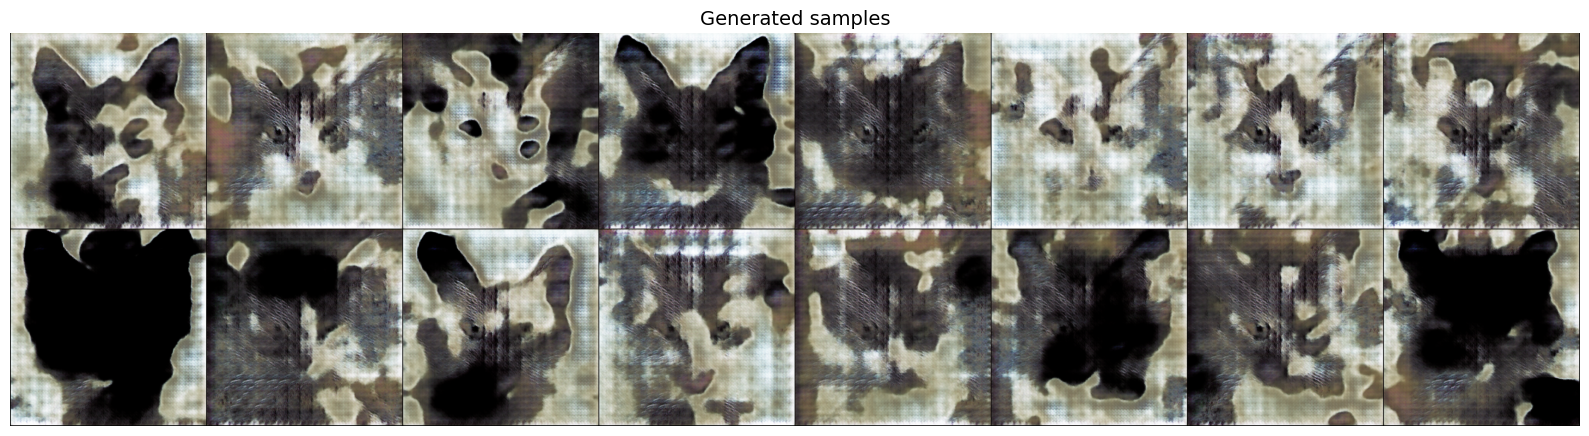

In [12]:
def show_samples(G, n=64, nrow=8, title='Generated samples'):
    with torch.no_grad():
        z = torch.randn(n, config.noise_dim, device=device)
        imgs = G(z).cpu().clamp(-1, 1)
        imgs = (imgs + 1) / 2          # [-1,1] → [0,1]

    grid = make_grid(imgs, nrow=nrow, padding=2)
    fig, ax = plt.subplots(figsize=(16, 16))
    ax.imshow(grid.permute(1, 2, 0))
    ax.axis('off')
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    return imgs

imgs = show_samples(G, n=16)

## D output distribution

In [ ]:
d_real_scores, d_fake_scores = [], []
config

with torch.no_grad():
    for (real_imgs, _) in tqdm(dataloader):
        real_imgs = real_imgs.to(device)
        z = torch.randn(len(real_imgs), config.noise_dim, device=device)
        fake_imgs = G(z)

        d_real = torch.sigmoid(D(real_imgs)).cpu().squeeze()
        d_fake = torch.sigmoid(D(fake_imgs)).cpu().squeeze()

        d_real_scores.append(d_real)
        d_fake_scores.append(d_fake)

d_real_scores = torch.cat(d_real_scores).numpy()
d_fake_scores = torch.cat(d_fake_scores).numpy()

print(f'D(real): mean={d_real_scores.mean():.3f}  std={d_real_scores.std():.3f}')
print(f'D(fake): mean={d_fake_scores.mean():.3f}  std={d_fake_scores.std():.3f}')
print(f'Balance (real-fake): {d_real_scores.mean() - d_fake_scores.mean():.3f}  (healthy: 0.3–0.5)')

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 40)
ax.hist(d_real_scores, bins=bins, alpha=0.6, label=f'D(real)  μ={d_real_scores.mean():.2f}', color='steelblue')
ax.hist(d_fake_scores, bins=bins, alpha=0.6, label=f'D(fake)  μ={d_fake_scores.mean():.2f}', color='tomato')
ax.axvline(0.5, color='k', linestyle='--', linewidth=1, label='0.5 threshold')
ax.set_xlabel('D output (after sigmoid)')
ax.set_ylabel('Count')
ax.set_title('Discriminator Output Distribution')
ax.legend()

# anomalies
if d_real_scores.mean() > 0.95:
    print('⚠️  D занадто впевнений у real → D домінує, спробуй ↑ n_g або ↓ D lr')
if d_fake_scores.mean() < 0.05:
    print('⚠️  D(fake) < 0.05 → можливий mode collapse або D занадто сильний')
if d_fake_scores.mean() > 0.6:
    print('⚠️  D(fake) > 0.6 → G fool-rate занадто висока, D не вчиться')

plt.tight_layout()
plt.show()

  0%|          | 0/354 [00:21<?, ?it/s]


KeyboardInterrupt: 